## Importing modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from classy import Class

### Importing from files

In [2]:
import sys
import os

# Add the parent directory to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

# Now import the module
from relativistic_degrees_of_freedom import RelativisticDegreesOfFreedom

In [3]:
# --- IMPORTING MAXIM DELTA NEFF CALCULATIONS
# Load the data from file
filename = "../Maxim-data/dNeff_fa_tau_dec.dat"  # Set the correct file path

# Read data while skipping the first row (header)
data = np.loadtxt(filename, delimiter=",", skiprows=1)

# Extract the first and third columns
fa_arr_MAXIM = data[:, 0]  # First column
delta_Neff_MAXIM = data[:, 2]  # Third column

N_distribution_Maxim = len(fa_arr_MAXIM)

In [4]:
# Now import module: evaluate A(log(m_a)), b(log(m_a)) and mu(log(m_a)) for muon scattering
from axion_production.taon_decay import evaluate_parameter

## Find today temperature of axion: $T_{\mathrm{ncdm}}$

More details about this calculation can be found in 2211.03799 on page: 13.

In [5]:
RelativisticDOF = RelativisticDegreesOfFreedom()

In [6]:
# --- Set axion process of production and corresponding dof ---
taon_mass = 1777*10**6  # [eV]
taon_mass_MeV = 1777 # [MeV]
x_dec_taon = 30  # decouple from the plasma
axion_decouple_dof = RelativisticDOF.compute_decoupling_dof(taon_mass, x_dec_taon)
print(f"taon mass: {taon_mass_MeV} [MeV], corresponds to: {axion_decouple_dof} relativistic dof of entropy")

# Set neutrinos decouple temperature and find corresponding dof
neutrino_decouple_T = 3*10**6  # 8.617 * 10**(-5) * 2.725, 3*10**6, [eV]
neutrino_decouple_dof = RelativisticDOF.get_degrees_of_freedom(neutrino_decouple_T, dof_type="g_eff_s")
print(f"kB*T for neutrino decouple: {neutrino_decouple_T*10**(-6)} [MeV]," 
      f"corresponds to: {neutrino_decouple_dof} relativistic dof of entropy")

taon mass: 1777 [MeV], corresponds to: 14.989432584994862 relativistic dof of entropy
kB*T for neutrino decouple: 3.0 [MeV],corresponds to: 10.721487622640407 relativistic dof of entropy


In [7]:
g_s_star_ratio = (neutrino_decouple_dof/axion_decouple_dof)
print("g_s_star_ratio:", g_s_star_ratio)

g_s_star_ratio: 0.7152697449917569


In [8]:
def calculate_T_axion(_g_s_star_ratio):
    """
    Calculate temperature of axion in selected process of production. For our reference
    T_nu = 0.71611 [T_gamma] is temperature of neutrinos. Variables `_g_s_star_ratio`:
    is the ratio between entropy degrees of freedom (dof) of axion (in moment of decople)
    and neutrinos (in moment of decouple).
    """
    # axion
    axion_decouple_dof = 15.4185
    # neutrinos
    neutrino_decouple_T = 3*10**6  # 8.617 * 10**(-5) * 2.725, 3*10**6, [eV]
    neutrino_decouple_dof = RelativisticDOF.get_degrees_of_freedom(neutrino_decouple_T, dof_type="g_eff_s")

    g_s_star_ratio = neutrino_decouple_dof/axion_decouple_dof
    return 0.71611 * (g_s_star_ratio)**(1/3) # in units of photon temperature [T_gamma]

## CLASS PART: Base parameters setting (we do not vary them)

In [9]:
def calculate_ma(fa):
    """
    Calculate the f_a value from a given axion mass m_a in eV based on the axion mass
    formula from particle physics. The relationship between the axion decay constant f_a
    and the axion mass m_a is given by the specific scale factor derived from theoretical
    models which predict f_a inversely proportional to m_a.

    This specific formula is referenced from a particle physics review publication:
    https://pdg.lbl.gov/2023/reviews/rpp2023-rev-axions.pdf

    Parameters:
    ma (float): The mass of the axion in eV.

    Returns:
    float: The axion decay constant f_a in GeV.
    """
    ma = (5.691 * 10 ** 6) / fa  # [GeV]
    return ma  # [GeV]

In [10]:
# --- Define the cosmological parameters for LambdaCDM + neutrinos + axions ---
params = {
    'output': 'mPk',  # Output: matter power spectrum
    'P_k_max_1/Mpc': 3.0,  # Maximum wavenumber for the power spectrum
    'h': 0.67556,          # Reduced Hubble parameter
    'omega_b': 0.022032,   # Baryon density
    'omega_cdm': 0.12038,  # Cold dark matter density
    'n_s': 0.9619,         # Spectral index
    'A_s': 2.215e-9,       # Amplitude of scalar perturbations
    'tau_reio': 0.0925,    # Optical depth to reionization

    # Neutrino and axion related parameters
    'N_ur': 0.0,
    'N_ncdm': '2',              # two species: neutrinos and axions
    'deg_ncdm': '3, 1',         # 3 degenerate neutrinos and axion

    # Basic settings
    # 'use_ncdm_psd_files': '0, 0',
    
    # Extra settings
    # 'perturbed_recombination': 'yes',       # consider perturbed recombination
    # 'ceff2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    # 'cvis2_ur': 1/3,                        # effective squared sound speed and viscosity parameter
    'ncdm_quadrature_strategy': '0, 0',      # is the method used for the momentum sampling of the ncdm distribution function: 0, 1, 2, 3
    # 'ncdm_maximum_q': '15, 15'
}

In [11]:
# the range of parameters, which we gonna investigate
# axion
axion_masses = calculate_ma(fa_arr_MAXIM)  # [eV]
Nums = len(axion_masses)
fa_CLASS_arr = []
# neutrinos
nuetrino_mass = 0.006  # [eV]
T_neutrinos = 0.71611  # in units of photon temperature [T_gamma]
# print(axion_masses)

# prepare list
Neff_base = 3.039594664360296
deltaNeff_list = []

### Varied parameters (axion masses and distribution)

In [12]:
cosmo_dict = {}
#
for i in range(0, 250):
    # --- Find physcial values
    m_a = axion_masses[i]  # [eV]
    log_m_a = np.log(m_a)  # [log(eV)]
    T_axion = calculate_T_axion(g_s_star_ratio) # in units of photon temperature [T_gamma]

    # --- appending
    fa_CLASS_arr.append(fa_arr_MAXIM[i])

    # --- Find parameters for selected axion masses
    A = evaluate_parameter("A", log_m_a)
    b = evaluate_parameter("b", log_m_a)
    mu = evaluate_parameter("mu", log_m_a)
    
    # --- Call CLASS
    if i % 10 == 0:
        print("I'm calculate for:", m_a, "[eV]", T_axion, "[T_gamma], index:", i)

    cosmo_dict[i] = Class()
    cosmo_dict[i].set(params)
    cosmo_dict[i].set({'m_ncdm': f'{nuetrino_mass}, {m_a}'})     # Masses of neutino and axion
    cosmo_dict[i].set({'T_ncdm': f'{T_neutrinos}, {T_axion}'})   # Temperature of neutino and axion
    cosmo_dict[i].set({'ncdm_psd_parameters': f'{A},{b},{mu}'})  # Axion distribution function
    cosmo_dict[i].compute()

I'm calculate for: 5.691 [eV] 0.6344304895777687 [T_gamma], index: 0
I'm calculate for: 4.517042090958498 [eV] 0.6344304895777687 [T_gamma], index: 10
I'm calculate for: 3.58525202099645 [eV] 0.6344304895777687 [T_gamma], index: 20
I'm calculate for: 2.845674624061675 [eV] 0.6344304895777687 [T_gamma], index: 30
I'm calculate for: 2.258659647524014 [eV] 0.6344304895777687 [T_gamma], index: 40
I'm calculate for: 1.7927360212643588 [eV] 0.6344304895777687 [T_gamma], index: 50
I'm calculate for: 1.4229246294198872 [eV] 0.6344304895777687 [T_gamma], index: 60
I'm calculate for: 1.1293991290372827 [eV] 0.6344304895777687 [T_gamma], index: 70
I'm calculate for: 0.8964230193908421 [eV] 0.6344304895777687 [T_gamma], index: 80
I'm calculate for: 0.7115059760837374 [eV] 0.6344304895777687 [T_gamma], index: 90
I'm calculate for: 0.5647342192828612 [eV] 0.6344304895777687 [T_gamma], index: 100
I'm calculate for: 0.44823901576265673 [eV] 0.6344304895777687 [T_gamma], index: 110
I'm calculate for: 0

In [13]:
# --- Finding all deltaNeff values
for i in range(0, 250):
    derived_params = cosmo_dict[i].get_current_derived_parameters(['Neff'])  # derived parameters
    deltaNeff = derived_params['Neff'] - Neff_base
    deltaNeff_list.append(deltaNeff)

print("lowest value of \Delta N_eff:", min(deltaNeff_list))

lowest value of \Delta N_eff: 0.025900418232092992


## Extra Relativistic Degrees of Freedom and Axion Mass: $\Delta N_{\mathrm{eff}}(m_\mathrm{a})$

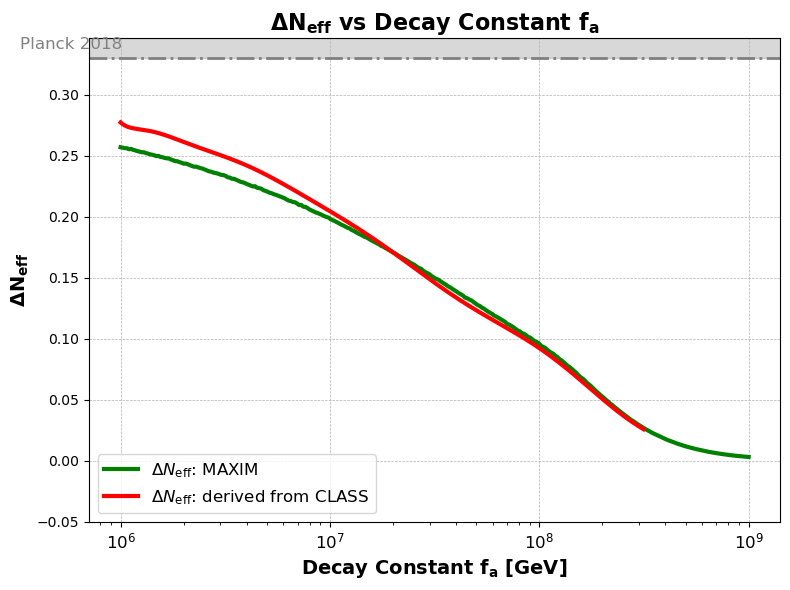

In [15]:
# Create the figure with improved aesthetics
fig, axs = plt.subplots(figsize=(8, 6))

# ---------------------------------------------------- SECOND PART OF PLOT ---------------------------------------------------- #
# Second plot: f_a vs Delta_N_eff with larger font size and thicker lines
axs.plot(fa_arr_MAXIM, delta_Neff_MAXIM, color='g', lw=3, label=r'$\Delta N_{\rm{eff}}$: MAXIM')
axs.plot(fa_CLASS_arr, deltaNeff_list, color='r', lw=3, label=r'$\Delta N_{\rm{eff}}$: derived from CLASS')
axs.set_xscale('log')
axs.set_xlabel(r'Decay Constant $\bf f_a$ [GeV]', fontsize=14, fontweight='bold')
axs.set_ylabel(r'$\bf \Delta N_{eff}$', fontsize=14, fontweight='bold')
axs.set_title(r'$\bf \Delta N_{eff}$ vs Decay Constant $\bf f_a$', fontsize=16, fontweight='bold')
axs.grid(True, linestyle='--', linewidth=0.5)
axs.legend(fontsize=12)

# --- Dashed-line
# Dashed-dotted line value for Planck 2018 constraint
planck_limit = 0.33

# Add dashed-dotted line for Planck 2018 limit
axs.axhline(planck_limit, color='gray', linestyle='-.', lw=2)

# Add text for Planck 2018 directly on the plot
axs.text(fa_CLASS_arr[1], planck_limit + 0.005, 'Planck 2018', color='gray', fontsize=12, va='bottom', ha='right')

# Fill the entire region above the Planck limit with gray shading
ymin, ymax = axs.get_ylim()
xmin, xmax = axs.get_xlim()
axs.set_xlim(xmin, xmax)
axs.set_ylim(-0.05, ymax)
xaxes = np.linspace(xmin, xmax, num=50)
axs.fill_between(xaxes, planck_limit, ymax,
                color='gray', alpha=0.3)

# --- Other settings
# Set x-axis ticks in log scale manner with explicit scientific formatting and increase tick size
axs.xaxis.set_major_locator(ticker.LogLocator(base=10.0))
axs.xaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: f'$10^{{{int(np.log10(val))}}}$'))
axs.tick_params(axis='x', which='major', labelsize=12)  # Increase x-axis tick size

# ---------------------------------------------------- SAVING PLOT ---------------------------------------------------- #
# Adjust layout and show the plot
plt.tight_layout()
plt.show()
# plt.savefig('Fits_of_delta_N_eff_and_axion_mass.png', format='png', dpi=300)
# plt.close()

In [16]:
# --- Check the differences between ΔN_eff_fit and ΔN_eff_points ---
print(f"{'Axion Mass [eV]':<20}{'ΔN_eff (Best)':>20}{'ΔN_eff (Fit)':>20}{'Rel. Diff. [%]':>20}")
print("=" * 80)

rel_diff_arr = []
for i in range(0, len(fa_CLASS_arr)):
    fa = fa_arr_MAXIM[i]

    # Find delta Neff
    N_eff = delta_Neff_MAXIM[i]  # Best values from distribution
    N_eff_CLASS = deltaNeff_list[i]

    # Compute relative difference in percentage
    rel_diff = 100 * abs(N_eff - N_eff_CLASS) / abs(N_eff) if N_eff != 0 else 0
    rel_diff_arr.append(rel_diff)

    print(f"{m_a:<20.6e}{N_eff:>20.6e}{N_eff_CLASS:>20.6e}{rel_diff:>20.6f}")

Axion Mass [eV]            ΔN_eff (Best)        ΔN_eff (Fit)      Rel. Diff. [%]
1.806595e-02                2.570522e-01        2.773637e-01            7.901709
1.806595e-02                2.566605e-01        2.759720e-01            7.524154
1.806595e-02                2.563464e-01        2.749010e-01            7.238126
1.806595e-02                2.562181e-01        2.740807e-01            6.971644
1.806595e-02                2.554176e-01        2.734524e-01            7.060906
1.806595e-02                2.556854e-01        2.729677e-01            6.759213
1.806595e-02                2.549018e-01        2.725861e-01            6.937715
1.806595e-02                2.544612e-01        2.722745e-01            7.000409
1.806595e-02                2.539007e-01        2.720059e-01            7.130813
1.806595e-02                2.534704e-01        2.717551e-01            7.213717
1.806595e-02                2.529394e-01        2.715113e-01            7.342455
1.806595e-02                

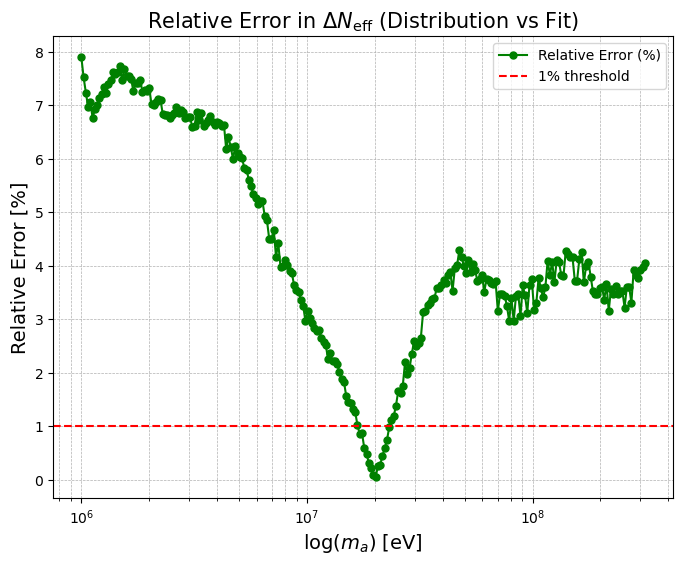

In [17]:
plt.figure(figsize=(8, 6))

# Plot relative error as a function of axion mass
plt.plot(fa_CLASS_arr, rel_diff_arr, 'go-', label=r'Relative Error (%)', markersize=5)

# Add a horizontal line at 1% to highlight the accuracy threshold
plt.axhline(y=1, color='r', linestyle='--', label='1% threshold')

plt.xlabel(r'$\log(m_a)$ [eV]', fontsize=14)
plt.ylabel(r'Relative Error [%]', fontsize=14)
plt.title(r'Relative Error in $\Delta N_{\mathrm{eff}}$ (Distribution vs Fit)', fontsize=15)

# Use logarithmic y-scale if errors span multiple orders of magnitude
plt.xscale("log")  

plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()